# 06 · Actor Crosswalk & 3-Way Validation

**Purpose:** Build a canonical crosswalk between actor names in ACLED, Wikipedia, and UCDP, then perform a direct actor-level 3-way validation.

**Context:** Prior notebooks (03, 04) used a *side-level expected label* approach — a Pro-junta gain implies an expected `government` status. This notebook goes deeper: it matches actors directly across all three databases at the cell-month level.

**Overlap window:** November 2023 – March 2026  
**Spatial unit:** PRIO-GRID cells (0.5° × 0.5°)

In [1]:
import sys
import warnings
import os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from pathlib import Path

# ── path setup ──────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path(os.path.abspath(''))
# When running as a notebook the cwd is notebook_training/
if NOTEBOOK_DIR.name != 'eda_analysis':
    NOTEBOOK_DIR = Path('/Users/felipe/Documents/BSE/Thesis/territorial_control_dsdm_master_project/notebooks/eda_analysis')

ROOT = NOTEBOOK_DIR.parent.parent

# add notebook_training to sys.path for actor_taxonomy import
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from actor_taxonomy import group_actors, ACTOR_RULES, TIME_RULES, INTER1_FALLBACK

# ── constants ────────────────────────────────────────────────────────────────
OVERLAP_START = '2023-11'
OVERLAP_END   = '2026-03'
POST_COUP     = pd.Timestamp('2021-02-01')
MAP_BOUNDS    = (92.0, 9.5, 101.5, 28.5)   # (lon_min, lat_min, lon_max, lat_max)

# ── output dirs ──────────────────────────────────────────────────────────────
(ROOT / 'data' / 'processed').mkdir(parents=True, exist_ok=True)
(NOTEBOOK_DIR.parent / 'checkpoints').mkdir(parents=True, exist_ok=True)
(ROOT / 'reports' / 'figures').mkdir(parents=True, exist_ok=True)

print('ROOT:', ROOT)
print('NOTEBOOK_DIR:', NOTEBOOK_DIR)

ROOT: /Users/felipe/Documents/BSE/Thesis/territorial_control_dsdm_master_project
NOTEBOOK_DIR: /Users/felipe/Documents/BSE/Thesis/territorial_control_dsdm_master_project/notebook_training


## Utility: PRIO-GRID GID formula

In [2]:
def latlon_to_priogrid_gid(lat: float, lon: float) -> int:
    """Convert WGS-84 lat/lon to PRIO-GRID GID (1-indexed)."""
    row = int((lat + 90)  / 0.5) + 1
    col = int((lon + 180) / 0.5) + 1
    return (row - 1) * 720 + col

# quick sanity check
assert latlon_to_priogrid_gid(16.87, 96.17) > 0
print('priogrid helper OK — Yangon GID:', latlon_to_priogrid_gid(16.87, 96.17))

priogrid helper OK — Yangon GID: 153913


---
## Section 1 · Actor Crosswalk

In [3]:
crosswalk_records = [
    {
        'canonical': 'Tatmadaw/SAC',
        'side': 'Pro-junta',
        'acled_actor_group': 'Tatmadaw',
        'wiki_actor': 'Military Forces of Myanmar (SAC)',
        'ucdp_code': 'Government of Myanmar (Burma)',
        'expected_wiki_status': 'government',
    },
    {
        'canonical': 'NUG/PDF',
        'side': 'Anti-junta',
        'acled_actor_group': "People's Defence Force",
        'wiki_actor': 'NUG/PDF resistance forces',
        'ucdp_code': 'NUG',
        'expected_wiki_status': 'resistance',
    },
    {
        'canonical': 'KIA',
        'side': 'Anti-junta',
        'acled_actor_group': 'Kachin Independence Army (KIA)',
        'wiki_actor': 'Kachin Independence Army (KIO/KIA)',
        'ucdp_code': 'KIO',
        'expected_wiki_status': 'ethnic_armed_group',
    },
    {
        'canonical': 'Arakan Army',
        'side': 'Anti-junta',
        'acled_actor_group': 'Arakan Army (AA)',
        'wiki_actor': 'Arakan Army (AA);Arakan Army / NUG-aligned',
        'ucdp_code': 'ULA',
        'expected_wiki_status': 'ethnic_armed_group',
    },
    {
        'canonical': 'TNLA',
        'side': 'Anti-junta',
        'acled_actor_group': 'TNLA',
        'wiki_actor': '(not labeled)',
        'ucdp_code': 'PSLF',
        'expected_wiki_status': 'ethnic_armed_group',
    },
    {
        'canonical': 'MNDAA',
        'side': 'Anti-junta',
        'acled_actor_group': 'MNDAA',
        'wiki_actor': '(not labeled)',
        'ucdp_code': 'MNDAA',
        'expected_wiki_status': 'ethnic_armed_group',
    },
    {
        'canonical': 'KNLA/KNU',
        'side': 'Anti-junta',
        'acled_actor_group': 'Karen National Liberation Army (KNLA)',
        'wiki_actor': '(not labeled)',
        'ucdp_code': 'KNU',
        'expected_wiki_status': 'ethnic_armed_group',
    },
    {
        'canonical': 'Karenni',
        'side': 'Anti-junta',
        'acled_actor_group': 'Karenni Army',
        'wiki_actor': '(not labeled)',
        'ucdp_code': 'KNPP',
        'expected_wiki_status': 'ethnic_armed_group',
    },
    {
        'canonical': 'Chinland/CNF',
        'side': 'Anti-junta',
        'acled_actor_group': 'Chinland Council',
        'wiki_actor': 'Chin ethnic armed groups (CDF/CNF)',
        'ucdp_code': 'CNF',
        'expected_wiki_status': 'ethnic_armed_group',
    },
    {
        'canonical': 'Chin Brotherhood',
        'side': 'Anti-junta',
        'acled_actor_group': 'Chin Brotherhood Alliance',
        'wiki_actor': 'Chin PDF / resistance forces',
        'ucdp_code': 'CNF',
        'expected_wiki_status': 'ethnic_armed_group',
    },
    {
        'canonical': 'RCSS',
        'side': 'Neutral',
        'acled_actor_group': 'RCSS / Shan State Army South',
        'wiki_actor': '(not labeled)',
        'ucdp_code': 'RCSS',
        'expected_wiki_status': 'ethnic_armed_group',
    },
    {
        'canonical': 'UWSA',
        'side': 'Neutral',
        'acled_actor_group': 'UWSA',
        'wiki_actor': 'United Wa State Army (UWSA)',
        'ucdp_code': 'UWSA',
        'expected_wiki_status': 'ethnic_armed_group',
    },
]

crosswalk = pd.DataFrame(crosswalk_records)
print(crosswalk.to_string(index=False))

       canonical       side                     acled_actor_group                                 wiki_actor                     ucdp_code expected_wiki_status
    Tatmadaw/SAC  Pro-junta                              Tatmadaw           Military Forces of Myanmar (SAC) Government of Myanmar (Burma)           government
         NUG/PDF Anti-junta                People's Defence Force                  NUG/PDF resistance forces                           NUG           resistance
             KIA Anti-junta        Kachin Independence Army (KIA)         Kachin Independence Army (KIO/KIA)                           KIO   ethnic_armed_group
     Arakan Army Anti-junta                      Arakan Army (AA) Arakan Army (AA);Arakan Army / NUG-aligned                           ULA   ethnic_armed_group
            TNLA Anti-junta                                  TNLA                              (not labeled)                          PSLF   ethnic_armed_group
           MNDAA Anti-junta             

In [4]:
# ── build lookup dictionaries for fast matching ───────────────────────────────

# acled_actor_group  → canonical
acled_to_canonical = dict(zip(crosswalk['acled_actor_group'], crosswalk['canonical']))

# ucdp_code → canonical  (one UCDP code can map to multiple canonicals, e.g. CNF)
ucdp_to_canonical: dict[str, list[str]] = {}
for _, row in crosswalk.iterrows():
    ucdp_to_canonical.setdefault(row['ucdp_code'], []).append(row['canonical'])

# wiki_actor string → canonical  (semicolon-separated entries)
wiki_to_canonical: dict[str, list[str]] = {}
for _, row in crosswalk.iterrows():
    for part in row['wiki_actor'].split(';'):
        part = part.strip()
        if part and part != '(not labeled)':
            wiki_to_canonical.setdefault(part, []).append(row['canonical'])

# acled_actor_group → side
acled_to_side = dict(zip(crosswalk['acled_actor_group'], crosswalk['side']))

# canonical → side
canonical_to_side = dict(zip(crosswalk['canonical'], crosswalk['side']))

# canonical → expected_wiki_status
canonical_to_expected_status = dict(zip(crosswalk['canonical'], crosswalk['expected_wiki_status']))

print('acled_to_canonical:', acled_to_canonical)
print('\nucdp_to_canonical:', ucdp_to_canonical)
print('\nwiki_to_canonical:', wiki_to_canonical)

acled_to_canonical: {'Tatmadaw': 'Tatmadaw/SAC', "People's Defence Force": 'NUG/PDF', 'Kachin Independence Army (KIA)': 'KIA', 'Arakan Army (AA)': 'Arakan Army', 'TNLA': 'TNLA', 'MNDAA': 'MNDAA', 'Karen National Liberation Army (KNLA)': 'KNLA/KNU', 'Karenni Army': 'Karenni', 'Chinland Council': 'Chinland/CNF', 'Chin Brotherhood Alliance': 'Chin Brotherhood', 'RCSS / Shan State Army South': 'RCSS', 'UWSA': 'UWSA'}

ucdp_to_canonical: {'Government of Myanmar (Burma)': ['Tatmadaw/SAC'], 'NUG': ['NUG/PDF'], 'KIO': ['KIA'], 'ULA': ['Arakan Army'], 'PSLF': ['TNLA'], 'MNDAA': ['MNDAA'], 'KNU': ['KNLA/KNU'], 'KNPP': ['Karenni'], 'CNF': ['Chinland/CNF', 'Chin Brotherhood'], 'RCSS': ['RCSS'], 'UWSA': ['UWSA']}

wiki_to_canonical: {'Military Forces of Myanmar (SAC)': ['Tatmadaw/SAC'], 'NUG/PDF resistance forces': ['NUG/PDF'], 'Kachin Independence Army (KIO/KIA)': ['KIA'], 'Arakan Army (AA)': ['Arakan Army'], 'Arakan Army / NUG-aligned': ['Arakan Army'], 'Chin ethnic armed groups (CDF/CNF)': ['Chi

In [5]:
# ── save crosswalk ────────────────────────────────────────────────────────────
crosswalk_path = ROOT / 'data' / 'processed' / 'actor_crosswalk.csv'
crosswalk.to_csv(crosswalk_path, index=False)
print(f'Saved: {crosswalk_path}')

Saved: /Users/felipe/Documents/BSE/Thesis/territorial_control_dsdm_master_project/data/processed/actor_crosswalk.csv


---
## Section 2 · Direct Actor-Level Re-scoring (ACLED × Wikipedia)

In [6]:
# ── load ACLED grouped parquet ────────────────────────────────────────────────
acled_grouped = pd.read_parquet(NOTEBOOK_DIR.parent / 'checkpoints' / 'myanmar_acled_grouped.parquet')
acled_grouped['event_date'] = pd.to_datetime(acled_grouped['event_date'])

# derive priogrid_gid from lat_bin / lon_bin (cell centres stored as bin edges)
# lat_bin and lon_bin in the grouped file are the lower-left corners
acled_grouped['priogrid_gid'] = acled_grouped.apply(
    lambda r: latlon_to_priogrid_gid(r['latitude'], r['longitude']), axis=1
)
acled_grouped['year_month'] = acled_grouped['event_date'].dt.to_period('M').astype(str)

print('ACLED grouped shape:', acled_grouped.shape)
print('Control-signal events:', acled_grouped['is_control_signal'].sum())

ACLED grouped shape: (105463, 41)
Control-signal events: 637


In [7]:
# ── Wikipedia raw groundtruth ─────────────────────────────────────────────────
wiki_raw = pd.read_csv(ROOT / 'data' / 'raw' / 'validation' / 'myanmar_wikipedia_temporal_groundtruth.csv')
wiki_raw['priogrid_gid'] = wiki_raw.apply(
    lambda r: latlon_to_priogrid_gid(r['lat'], r['lon']), axis=1
)
wiki_raw['year_month'] = pd.to_datetime(wiki_raw['date']).dt.to_period('M').astype(str)

print('Wiki raw shape:', wiki_raw.shape)
print('Date range:', wiki_raw['date'].min(), '→', wiki_raw['date'].max())

Wiki raw shape: (8035, 10)
Date range: 2023-11-30 → 2026-03-30


In [8]:
# ── Wikipedia cell-month actor aggregation (dominant actor by majority vote) ──
wiki_actor_cell = (
    wiki_raw.groupby(['priogrid_gid', 'year_month'])['actor']
    .agg(lambda x: x.value_counts().index[0] if len(x) > 0 else None)
    .reset_index()
    .rename(columns={'actor': 'dominant_wiki_actor'})
)

# also get dominant control_status per cell-month
wiki_status_cell = (
    wiki_raw.groupby(['priogrid_gid', 'year_month'])['control_status']
    .agg(lambda x: x.value_counts().index[0] if len(x) > 0 else None)
    .reset_index()
    .rename(columns={'control_status': 'dominant_control_status'})
)

wiki_cell = wiki_actor_cell.merge(wiki_status_cell, on=['priogrid_gid', 'year_month'], how='left')
print('Wiki cell-month records:', len(wiki_cell))
print(wiki_cell.head(5))

Wiki cell-month records: 4345
   priogrid_gid year_month               dominant_wiki_actor  \
0        143838    2023-11  Military Forces of Myanmar (SAC)   
1        143838    2023-12  Military Forces of Myanmar (SAC)   
2        143838    2024-01  Military Forces of Myanmar (SAC)   
3        143838    2024-02  Military Forces of Myanmar (SAC)   
4        143838    2024-03  Military Forces of Myanmar (SAC)   

  dominant_control_status  
0              government  
1              government  
2              government  
3              government  
4              government  


In [9]:
# ── ACLED: dominant actor_group per cell-month (control-signal events) ─────────
acled_ctrl = acled_grouped[acled_grouped['is_control_signal']].copy()

acled_cell = (
    acled_ctrl.groupby(['priogrid_gid', 'year_month'])['actor_group']
    .agg(lambda x: x.value_counts().index[0] if len(x) > 0 else None)
    .reset_index()
    .rename(columns={'actor_group': 'acled_actor_group'})
)

print('ACLED cell-month control-signal records:', len(acled_cell))
print(acled_cell.head(5))

ACLED cell-month control-signal records: 405
   priogrid_gid year_month                      acled_actor_group
0        145998    2024-03                               Unmapped
1        145998    2024-05  Karen National Liberation Army (KNLA)
2        146720    2025-11  Karen National Liberation Army (KNLA)
3        147438    2024-04  Karen National Liberation Army (KNLA)
4        148878    2024-05  Karen National Liberation Army (KNLA)


In [10]:
# ── helper: resolve wiki_actor string → canonical actors ────────────────────────
def resolve_wiki_actor_to_canonical(wiki_actor_str: str) -> list[str]:
    """Return list of canonical actors mentioned in a wiki_actor string."""
    if not isinstance(wiki_actor_str, str):
        return []
    found = []
    for key, canonicals in wiki_to_canonical.items():
        if key in wiki_actor_str:
            found.extend(canonicals)
    return list(set(found))


def compute_actor_score(acled_ag: str, wiki_actor_str: str) -> float:
    """
    Actor-level agreement score between an ACLED actor_group and a Wikipedia actor string.
    1.0 → direct match
    0.5 → contested mention (SAC vs X or X vs SAC)
    0.0 → no mention
    NaN → missing data
    """
    if not isinstance(acled_ag, str) or not isinstance(wiki_actor_str, str):
        return float('nan')
    canonical = acled_to_canonical.get(acled_ag)
    if canonical is None:
        return float('nan')
    # get the wiki_actor strings for this canonical
    row = crosswalk[crosswalk['canonical'] == canonical]
    if row.empty:
        return float('nan')
    wiki_targets = [t.strip() for t in row.iloc[0]['wiki_actor'].split(';')
                    if t.strip() != '(not labeled)']
    if not wiki_targets:
        return float('nan')

    # direct match
    if any(t in wiki_actor_str for t in wiki_targets):
        return 1.0

    # contested mention: 'SAC vs X' or 'X vs SAC' where X partially matches
    if 'vs' in wiki_actor_str.lower():
        for t in wiki_targets:
            # use the first significant word of the target
            keyword = t.split('(')[0].strip().split()[-1]
            if keyword.lower() in wiki_actor_str.lower():
                return 0.5

    return 0.0


def compute_status_score(acled_ag: str, actual_status: str) -> float:
    """
    Status-level agreement score (same as NB04).
    1.0 → expected_wiki_status == actual control_status
    0.5 → either is 'contested'
    0.0 → clear mismatch
    NaN → missing
    """
    if not isinstance(acled_ag, str) or not isinstance(actual_status, str):
        return float('nan')
    canonical = acled_to_canonical.get(acled_ag)
    if canonical is None:
        return float('nan')
    expected = canonical_to_expected_status.get(canonical)
    if expected is None:
        return float('nan')
    if expected == actual_status:
        return 1.0
    if 'contested' in actual_status or 'contested' in expected:
        return 0.5
    return 0.0


print('Scoring helpers defined.')

Scoring helpers defined.


In [11]:
# ── Join ACLED cell-month with Wikipedia cell-month ───────────────────────────
# Use overlap window
acled_ctrl_ov = acled_cell[
    (acled_cell['year_month'] >= OVERLAP_START) &
    (acled_cell['year_month'] <= OVERLAP_END)
].copy()

wiki_cell_ov = wiki_cell[
    (wiki_cell['year_month'] >= OVERLAP_START) &
    (wiki_cell['year_month'] <= OVERLAP_END)
].copy()

acled_wiki = wiki_cell_ov.merge(acled_ctrl_ov, on=['priogrid_gid', 'year_month'], how='left')

# score
acled_wiki['status_score'] = acled_wiki.apply(
    lambda r: compute_status_score(r['acled_actor_group'], r['dominant_control_status']), axis=1
)
acled_wiki['actor_score'] = acled_wiki.apply(
    lambda r: compute_actor_score(r['acled_actor_group'], r['dominant_wiki_actor']), axis=1
)

print('ACLED × Wiki joined shape:', acled_wiki.shape)
print('\nRows with ACLED data:', acled_wiki['acled_actor_group'].notna().sum())
print('Rows with both scores:', acled_wiki[['status_score','actor_score']].notna().all(axis=1).sum())

ACLED × Wiki joined shape: (4345, 7)

Rows with ACLED data: 196
Rows with both scores: 137


N scoreable cell-months: 137
Status-level mean score : 0.361  (full match 21.2%)
Actor-level  mean score : 0.365  (full match 30.7%)


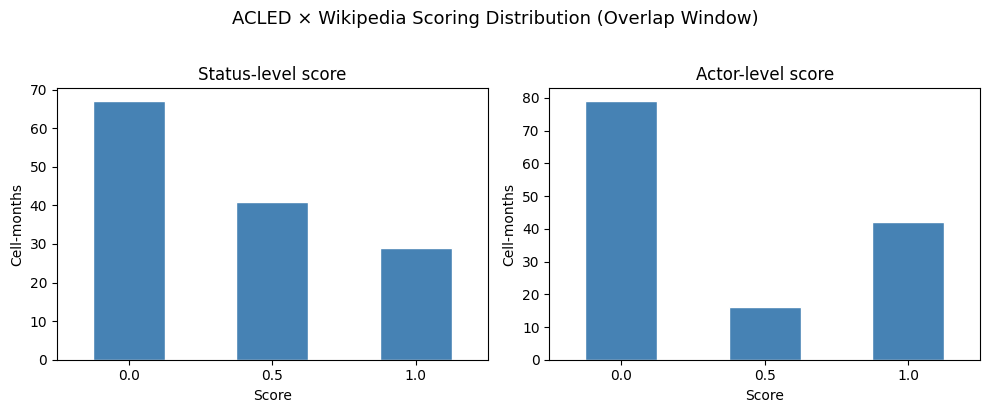

In [12]:
# ── Score comparison ──────────────────────────────────────────────────────────
scored = acled_wiki.dropna(subset=['status_score', 'actor_score'])

status_mean  = scored['status_score'].mean()
actor_mean   = scored['actor_score'].mean()
status_full  = (scored['status_score'] == 1.0).mean()
actor_full   = (scored['actor_score']  == 1.0).mean()

print(f'N scoreable cell-months: {len(scored)}')
print(f'Status-level mean score : {status_mean:.3f}  (full match {status_full:.1%})')
print(f'Actor-level  mean score : {actor_mean:.3f}  (full match {actor_full:.1%})')

# distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, title in zip(
    axes,
    ['status_score', 'actor_score'],
    ['Status-level score', 'Actor-level score']
):
    scored[col].value_counts(dropna=True).sort_index().plot.bar(ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Score')
    ax.set_ylabel('Cell-months')
    ax.set_xticklabels([f'{v:.1f}' for v in sorted(scored[col].dropna().unique())], rotation=0)
plt.suptitle('ACLED × Wikipedia Scoring Distribution (Overlap Window)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [13]:
# ── Actor breakdown ───────────────────────────────────────────────────────────
actor_breakdown = (
    scored.groupby('acled_actor_group')[['status_score', 'actor_score']]
    .agg(['mean', 'count'])
    .round(3)
)
actor_breakdown.columns = ['status_mean', 'status_n', 'actor_mean', 'actor_n']
print(actor_breakdown.sort_values('actor_n', ascending=False).to_string())

                                status_mean  status_n  actor_mean  actor_n
acled_actor_group                                                         
Arakan Army (AA)                      0.218        39       0.615       39
Kachin Independence Army (KIA)        0.457        35       0.314       35
Tatmadaw                              0.533        30       0.433       30
People's Defence Force                0.159        22       0.091       22
Chin Brotherhood Alliance             0.750         6       0.000        6
Chinland Council                      0.250         4       0.000        4
UWSA                                  0.000         1       0.000        1


---
## Section 3 · UCDP Actor Aggregation per Cell-Month

In [14]:
# ── load UCDP merged ──────────────────────────────────────────────────────────
ucdp_raw = pd.read_csv(ROOT / 'data' / 'raw' / 'ucdp' / 'GEDEvent_myanmar_merged.csv')
ucdp_raw['date_start'] = pd.to_datetime(ucdp_raw['date_start'])

# filter: precision ≤ 5 (same as step8_priogrid_features) and post-coup
ucdp = ucdp_raw[
    (ucdp_raw['where_prec'] <= 5) &
    (ucdp_raw['date_start'] >= POST_COUP)
].copy()

ucdp['year_month'] = ucdp['date_start'].dt.to_period('M').astype(str)

print('UCDP raw:', ucdp_raw.shape)
print('UCDP post-coup, prec ≤ 5:', ucdp.shape)
print('Date range:', ucdp['date_start'].min().date(), '→', ucdp['date_start'].max().date())

UCDP raw: (9336, 25)
UCDP post-coup, prec ≤ 5: (6445, 26)
Date range: 2021-02-09 → 2026-03-31


In [15]:
# ── filter to overlap window ───────────────────────────────────────────────────
ucdp_ov = ucdp[
    (ucdp['year_month'] >= OVERLAP_START) &
    (ucdp['year_month'] <= OVERLAP_END)
].copy()

print('UCDP overlap window records:', len(ucdp_ov))
print('Cells in UCDP overlap:', ucdp_ov['priogrid_gid'].nunique())

UCDP overlap window records: 2260
Cells in UCDP overlap: 160


In [16]:
# ── UCDP cell-month aggregation ────────────────────────────────────────────────
EXCLUDE_SIDE_B = {'Civilians', 'Government of Myanmar (Burma)'}

ucdp_non_gov = ucdp_ov[~ucdp_ov['side_b'].isin(EXCLUDE_SIDE_B)].copy()

def dominant_side_b(x):
    vc = x.value_counts()
    return vc.index[0] if len(vc) > 0 else None

def dominant_dyad(x):
    vc = x.value_counts()
    return vc.index[0] if len(vc) > 0 else None

ucdp_cell = (
    ucdp_non_gov.groupby(['priogrid_gid', 'year_month'])
    .agg(
        dominant_side_b=('side_b',  dominant_side_b),
        dominant_dyad   =('dyad_name', dominant_dyad),
        n_ucdp_events   =('id',     'count'),
        total_fatalities=('best',   'sum'),
    )
    .reset_index()
)

print('UCDP cell-month records (non-gov side_b):', len(ucdp_cell))
print(ucdp_cell.head(5).to_string())

UCDP cell-month records (non-gov side_b): 1084
   priogrid_gid year_month dominant_side_b                        dominant_dyad  n_ucdp_events  total_fatalities
0        145278    2026-02             KNU  Government of Myanmar (Burma) - KNU              1                 1
1        145999    2025-05             NUG  Government of Myanmar (Burma) - NUG              1                 1
2        146719    2025-09             KNU  Government of Myanmar (Burma) - KNU              1                 0
3        147437    2023-12             NUG  Government of Myanmar (Burma) - NUG              1                 0
4        147438    2024-01             NUG  Government of Myanmar (Burma) - NUG              1                 0


In [17]:
# ── also aggregate all (including gov) for full event/fatality counts ─────────
ucdp_cell_all = (
    ucdp_ov.groupby(['priogrid_gid', 'year_month'])
    .agg(
        n_ucdp_total=('id', 'count'),
        total_fatalities_all=('best', 'sum'),
    )
    .reset_index()
)
ucdp_cell = ucdp_cell.merge(ucdp_cell_all, on=['priogrid_gid', 'year_month'], how='left')

print('UCDP dominant side_b distribution:')
print(ucdp_cell['dominant_side_b'].value_counts().head(15).to_string())

UCDP dominant side_b distribution:
dominant_side_b
NUG      581
ULA      144
KNU      130
KIO       85
PSLF      74
KNPP      32
CNF       14
MNDAA     10
PNLO       8
ABSDF      2
SCEF       1
SSPP       1
RCSS       1
UNLFW      1


---
## Section 4 · 3-Way Validation

In [18]:
# ── load Wikipedia cell labels (priogrid-level) ───────────────────────────────
wiki_labels = pd.read_csv(ROOT / 'data' / 'processed' / 'myanmar_priogrid_labels.csv')
wiki_labels['year_month'] = wiki_labels['year_month'].astype(str)
wiki_labels_ov = wiki_labels[
    (wiki_labels['year_month'] >= OVERLAP_START) &
    (wiki_labels['year_month'] <= OVERLAP_END)
].copy()

print('Wikipedia cell labels (overlap):', len(wiki_labels_ov))

Wikipedia cell labels (overlap): 5238


In [19]:
# ── build 3-way panel ─────────────────────────────────────────────────────────
# base: Wikipedia labels (all cells that have a Wiki observation)
panel = wiki_labels_ov[['priogrid_gid', 'year_month', 'control_status']].copy()
panel = panel.rename(columns={'control_status': 'wiki_control_status'})

# join Wikipedia actor
panel = panel.merge(wiki_cell_ov[['priogrid_gid', 'year_month', 'dominant_wiki_actor']],
                    on=['priogrid_gid', 'year_month'], how='left')

# join ACLED
panel = panel.merge(acled_ctrl_ov[['priogrid_gid', 'year_month', 'acled_actor_group']],
                    on=['priogrid_gid', 'year_month'], how='left')

# join UCDP
panel = panel.merge(
    ucdp_cell[['priogrid_gid', 'year_month', 'dominant_side_b', 'dominant_dyad',
                'n_ucdp_events', 'total_fatalities']],
    on=['priogrid_gid', 'year_month'], how='left'
)

print('3-way panel shape:', panel.shape)
print(panel.head(5).to_string())

3-way panel shape: (5238, 9)
   priogrid_gid year_month wiki_control_status               dominant_wiki_actor acled_actor_group dominant_side_b dominant_dyad  n_ucdp_events  total_fatalities
0        143838    2023-11          government  Military Forces of Myanmar (SAC)               NaN             NaN           NaN            NaN               NaN
1        143838    2023-12          government  Military Forces of Myanmar (SAC)               NaN             NaN           NaN            NaN               NaN
2        143838    2024-01          government  Military Forces of Myanmar (SAC)               NaN             NaN           NaN            NaN               NaN
3        143838    2024-02          government  Military Forces of Myanmar (SAC)               NaN             NaN           NaN            NaN               NaN
4        143838    2024-03          government  Military Forces of Myanmar (SAC)               NaN             NaN           NaN            NaN               NaN

In [20]:
# ── resolve canonical actors for each source ──────────────────────────────────

def acled_to_canonical_fn(ag: str) -> str | None:
    if not isinstance(ag, str):
        return None
    return acled_to_canonical.get(ag)

def ucdp_to_canonical_fn(side_b: str) -> str | None:
    """Return first canonical match for a UCDP side_b code."""
    if not isinstance(side_b, str):
        return None
    canonicals = ucdp_to_canonical.get(side_b, [])
    return canonicals[0] if canonicals else None

def wiki_actor_to_canonical_fn(wiki_actor_str: str) -> str | None:
    """Return first canonical match found in a wiki_actor string."""
    if not isinstance(wiki_actor_str, str):
        return None
    for key, canonicals in wiki_to_canonical.items():
        if key in wiki_actor_str:
            return canonicals[0]
    return None

panel['canonical_acled'] = panel['acled_actor_group'].map(acled_to_canonical_fn)
panel['canonical_ucdp']  = panel['dominant_side_b'].map(ucdp_to_canonical_fn)
panel['canonical_wiki']  = panel['dominant_wiki_actor'].map(wiki_actor_to_canonical_fn)

# side mappings
panel['side_acled'] = panel['canonical_acled'].map(canonical_to_side)
panel['side_ucdp']  = panel['canonical_ucdp'].map(canonical_to_side)
panel['side_wiki']  = panel['canonical_wiki'].map(canonical_to_side)

print('Canonical resolution counts:')
print('  ACLED resolved:', panel['canonical_acled'].notna().sum())
print('  UCDP resolved: ', panel['canonical_ucdp'].notna().sum())
print('  Wiki resolved: ', panel['canonical_wiki'].notna().sum())

Canonical resolution counts:
  ACLED resolved: 187
  UCDP resolved:  951
  Wiki resolved:  3358


In [21]:
# ── agreement flags ───────────────────────────────────────────────────────────

def canonical_agree(a: str | None, b: str | None) -> bool | None:
    """True if both non-null and equal."""
    if pd.isna(a) or pd.isna(b):
        return None
    return a == b

def side_agree(a: str | None, b: str | None) -> bool | None:
    if pd.isna(a) or pd.isna(b):
        return None
    return a == b

panel['agree_acled_wiki_canonical'] = panel.apply(
    lambda r: canonical_agree(r['canonical_acled'], r['canonical_wiki']), axis=1)
panel['agree_acled_ucdp_canonical'] = panel.apply(
    lambda r: canonical_agree(r['canonical_acled'], r['canonical_ucdp']), axis=1)
panel['agree_wiki_ucdp_canonical']  = panel.apply(
    lambda r: canonical_agree(r['canonical_wiki'],  r['canonical_ucdp']), axis=1)

panel['agree_acled_wiki_side'] = panel.apply(
    lambda r: side_agree(r['side_acled'], r['side_wiki']), axis=1)
panel['agree_acled_ucdp_side'] = panel.apply(
    lambda r: side_agree(r['side_acled'], r['side_ucdp']), axis=1)
panel['agree_wiki_ucdp_side']  = panel.apply(
    lambda r: side_agree(r['side_wiki'],  r['side_ucdp']), axis=1)

# 3-way agreement
panel['threeway_canonical'] = panel.apply(
    lambda r: (
        pd.notna(r['canonical_acled']) and
        pd.notna(r['canonical_wiki'])  and
        pd.notna(r['canonical_ucdp'])  and
        r['canonical_acled'] == r['canonical_wiki'] == r['canonical_ucdp']
    ), axis=1
)
panel['threeway_side'] = panel.apply(
    lambda r: (
        pd.notna(r['side_acled']) and
        pd.notna(r['side_wiki'])  and
        pd.notna(r['side_ucdp'])  and
        r['side_acled'] == r['side_wiki'] == r['side_ucdp']
    ), axis=1
)

# data availability indicator
panel['n_sources'] = (
    panel['canonical_acled'].notna().astype(int) +
    panel['canonical_wiki'].notna().astype(int)  +
    panel['canonical_ucdp'].notna().astype(int)
)

print('panel columns:', panel.columns.tolist())

panel columns: ['priogrid_gid', 'year_month', 'wiki_control_status', 'dominant_wiki_actor', 'acled_actor_group', 'dominant_side_b', 'dominant_dyad', 'n_ucdp_events', 'total_fatalities', 'canonical_acled', 'canonical_ucdp', 'canonical_wiki', 'side_acled', 'side_ucdp', 'side_wiki', 'agree_acled_wiki_canonical', 'agree_acled_ucdp_canonical', 'agree_wiki_ucdp_canonical', 'agree_acled_wiki_side', 'agree_acled_ucdp_side', 'agree_wiki_ucdp_side', 'threeway_canonical', 'threeway_side', 'n_sources']


In [22]:
# ── summary statistics ────────────────────────────────────────────────────────
all3 = panel[panel['n_sources'] == 3]
at_least_2 = panel[panel['n_sources'] >= 2]

print('='*60)
print('3-WAY PANEL SUMMARY')
print('='*60)
print(f'Total cell-months (Wiki base):   {len(panel):>6}')
print(f'Cell-months with all 3 sources:  {len(all3):>6}')
print(f'Cell-months with ≥ 2 sources:    {len(at_least_2):>6}')
print()
print('--- Among cell-months with all 3 sources ---')
if len(all3) > 0:
    tw_can = all3['threeway_canonical'].mean()
    tw_sid = all3['threeway_side'].mean()
    aw_can = all3['agree_acled_wiki_canonical'].mean()
    au_can = all3['agree_acled_ucdp_canonical'].mean()
    wu_can = all3['agree_wiki_ucdp_canonical'].mean()
    print(f'  3-way full canonical agreement:  {tw_can:.1%}')
    print(f'  3-way side agreement:            {tw_sid:.1%}')
    print(f'  ACLED-Wikipedia (canonical):     {aw_can:.1%}')
    print(f'  ACLED-UCDP (canonical):          {au_can:.1%}')
    print(f'  Wikipedia-UCDP (canonical):      {wu_can:.1%}')
print()
print('--- Among cell-months with ≥ 2 sources ---')
if len(at_least_2) > 0:
    aw2 = at_least_2['agree_acled_wiki_canonical'].dropna().mean()
    au2 = at_least_2['agree_acled_ucdp_canonical'].dropna().mean()
    wu2 = at_least_2['agree_wiki_ucdp_canonical'].dropna().mean()
    print(f'  ACLED-Wikipedia (canonical):     {aw2:.1%}  (n={at_least_2["agree_acled_wiki_canonical"].notna().sum()})')
    print(f'  ACLED-UCDP (canonical):          {au2:.1%}  (n={at_least_2["agree_acled_ucdp_canonical"].notna().sum()})')
    print(f'  Wikipedia-UCDP (canonical):      {wu2:.1%}  (n={at_least_2["agree_wiki_ucdp_canonical"].notna().sum()})')

3-WAY PANEL SUMMARY
Total cell-months (Wiki base):     5238
Cell-months with all 3 sources:      51
Cell-months with ≥ 2 sources:       594

--- Among cell-months with all 3 sources ---
  3-way full canonical agreement:  29.4%
  3-way side agreement:            39.2%
  ACLED-Wikipedia (canonical):     41.2%
  ACLED-UCDP (canonical):          62.7%
  Wikipedia-UCDP (canonical):      39.2%

--- Among cell-months with ≥ 2 sources ---
  ACLED-Wikipedia (canonical):     39.3%  (n=107)
  ACLED-UCDP (canonical):          65.4%  (n=104)
  Wikipedia-UCDP (canonical):      16.3%  (n=485)


In [23]:
# ── breakdown by canonical actor ──────────────────────────────────────────────
breakdown_cols = ['canonical_acled', 'threeway_canonical', 'threeway_side',
                  'agree_acled_wiki_canonical', 'agree_acled_ucdp_canonical']

if len(all3) > 0:
    actor_summary = (
        all3.groupby('canonical_acled')
        .agg(
            n_cell_months=('threeway_canonical', 'count'),
            pct_3way_canonical=('threeway_canonical', 'mean'),
            pct_3way_side=('threeway_side', 'mean'),
            pct_aw=('agree_acled_wiki_canonical', 'mean'),
            pct_au=('agree_acled_ucdp_canonical', 'mean'),
        )
        .round(3)
        .sort_values('n_cell_months', ascending=False)
    )
    print('Breakdown by canonical ACLED actor (cell-months with all 3 sources):')
    print(actor_summary.to_string())
else:
    print('No cell-months with all 3 sources — showing pairwise breakdown.')
    if len(at_least_2) > 0:
        pairwise = (
            at_least_2[at_least_2['agree_acled_wiki_canonical'].notna()]
            .groupby('canonical_acled')
            .agg(
                n=('agree_acled_wiki_canonical', 'count'),
                pct_aw=('agree_acled_wiki_canonical', 'mean'),
            )
            .round(3)
            .sort_values('n', ascending=False)
        )
        print(pairwise.to_string())

Breakdown by canonical ACLED actor (cell-months with all 3 sources):
                 n_cell_months  pct_3way_canonical  pct_3way_side    pct_aw    pct_au
canonical_acled                                                                      
Arakan Army                 15               0.800          0.800       0.8  0.933333
Tatmadaw/SAC                12               0.000          0.000       0.5       0.0
NUG/PDF                      8               0.125          0.250     0.125       0.5
KIA                          7               0.286          0.571  0.285714  0.857143
KNLA/KNU                     3               0.000          0.000       0.0       1.0
TNLA                         3               0.000          0.333       0.0  0.666667
MNDAA                        2               0.000          0.000       0.0       1.0
Chinland/CNF                 1               0.000          1.000       0.0       1.0


In [24]:
# ── breakdown by side ─────────────────────────────────────────────────────────
side_col = 'side_acled'
by_side = (
    panel[panel[side_col].notna()]
    .groupby(side_col)
    .agg(
        n_cell_months=(side_col, 'count'),
        pct_aw_side=('agree_acled_wiki_side', lambda x: x.dropna().mean() if x.notna().any() else float('nan')),
        pct_au_side=('agree_acled_ucdp_side', lambda x: x.dropna().mean() if x.notna().any() else float('nan')),
    )
    .round(3)
    .sort_values('n_cell_months', ascending=False)
)
print('\nBreakdown by ACLED side:')
print(by_side.to_string())


Breakdown by ACLED side:
            n_cell_months  pct_aw_side  pct_au_side
side_acled                                         
Anti-junta            152        0.494          1.0
Pro-junta              34        0.542          0.0
Neutral                 1          NaN          0.0


In [25]:
# ── save 3-way panel ──────────────────────────────────────────────────────────
panel_path = NOTEBOOK_DIR.parent / 'checkpoints' / 'three_way_panel.parquet'
panel.to_parquet(panel_path, index=False)
print(f'Saved 3-way panel: {panel_path}')
print(f'Shape: {panel.shape}')

Saved 3-way panel: /Users/felipe/Documents/BSE/Thesis/territorial_control_dsdm_master_project/notebook_training/checkpoints/three_way_panel.parquet
Shape: (5238, 24)


---
## Section 5 · Maps

In [26]:
# ── load GADM admin-1 boundaries ──────────────────────────────────────────────
gadm = gpd.read_file(
    ROOT / 'data' / 'raw' / 'gadm' / 'gadm41_MMR.gpkg',
    layer='ADM_ADM_1'
).to_crs('EPSG:4326')
print('GADM admin-1 loaded:', gadm.shape)

GADM admin-1 loaded: (15, 12)


In [27]:
# ── helper: build cell-level GeoDataFrame from panel ─────────────────────────
def priogrid_to_polygon(gid: int):
    """Return (lon_min, lat_min, lon_max, lat_max) for a PRIO-GRID cell."""
    row = (gid - 1) // 720          # 0-indexed row from south
    col = (gid - 1) %  720          # 0-indexed col from west
    lat_min = row * 0.5 - 90
    lon_min = col * 0.5 - 180
    return lon_min, lat_min, lon_min + 0.5, lat_min + 0.5

from shapely.geometry import box

def make_cell_gdf(df: pd.DataFrame, value_col: str, agg='first') -> gpd.GeoDataFrame:
    """Aggregate panel to one row per cell and attach geometry."""
    if agg == 'first':
        cell_df = df.groupby('priogrid_gid')[value_col].first().reset_index()
    else:
        cell_df = df.groupby('priogrid_gid')[value_col].agg(agg).reset_index()
    cell_df['geometry'] = cell_df['priogrid_gid'].apply(
        lambda gid: box(*priogrid_to_polygon(gid))
    )
    return gpd.GeoDataFrame(cell_df, crs='EPSG:4326')

print('Cell geometry helper defined.')

Cell geometry helper defined.


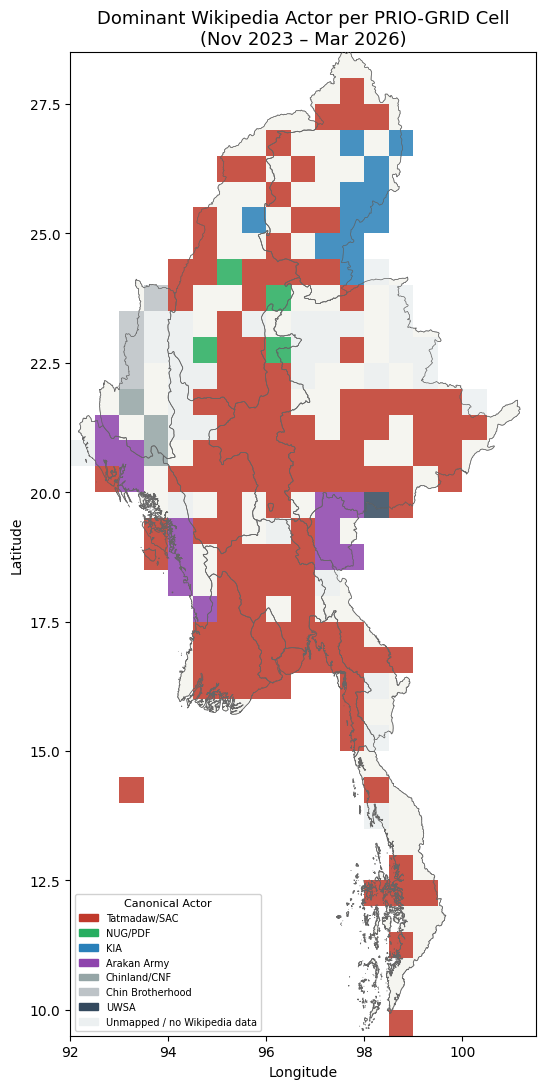

Saved: /Users/felipe/Documents/BSE/Thesis/territorial_control_dsdm_master_project/reports/figures/wiki_actor_map.png


In [28]:
# ── Map 1: dominant Wikipedia actor per cell (overlap window) ─────────────────

# aggregate: dominant wiki_actor across the whole overlap window per cell
wiki_dominant_overall = (
    wiki_cell_ov.groupby('priogrid_gid')['dominant_wiki_actor']
    .agg(lambda x: x.value_counts().index[0] if len(x) > 0 else None)
    .reset_index()
)
wiki_dominant_overall['canonical_wiki'] = wiki_dominant_overall['dominant_wiki_actor'].map(
    wiki_actor_to_canonical_fn
)

# color palette per canonical
canonical_palette = {
    'Tatmadaw/SAC':   '#c0392b',  # red
    'NUG/PDF':        '#27ae60',  # green
    'KIA':            '#2980b9',  # blue
    'Arakan Army':    '#8e44ad',  # purple
    'TNLA':           '#16a085',  # teal
    'MNDAA':          '#f39c12',  # orange
    'KNLA/KNU':       '#1abc9c',  # mint
    'Karenni':        '#e67e22',  # dark orange
    'Chinland/CNF':   '#95a5a6',  # grey-blue
    'Chin Brotherhood':'#bdc3c7', # light grey
    'RCSS':           '#7f8c8d',  # dark grey
    'UWSA':           '#34495e',  # slate
    None:             '#ecf0f1',  # near-white for unmapped
}

wiki_dominant_overall['color'] = wiki_dominant_overall['canonical_wiki'].map(
    lambda c: canonical_palette.get(c, '#ecf0f1')
)

cell_gdf1 = make_cell_gdf(wiki_dominant_overall, 'color')

fig, ax = plt.subplots(figsize=(8, 11))
lon_min, lat_min, lon_max, lat_max = MAP_BOUNDS
ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)

gadm.plot(ax=ax, color='#f5f5f0', edgecolor='#999999', linewidth=0.5, zorder=1)
cell_gdf1.plot(ax=ax, color=cell_gdf1['color'], edgecolor='none', alpha=0.85, zorder=2)
gadm.boundary.plot(ax=ax, color='#666666', linewidth=0.5, zorder=3)

# legend
legend_entries = [
    (label, color)
    for label, color in canonical_palette.items()
    if label is not None and label in wiki_dominant_overall['canonical_wiki'].values
]
patches = [mpatches.Patch(color=c, label=l) for l, c in legend_entries]
patches.append(mpatches.Patch(color='#ecf0f1', label='Unmapped / no Wikipedia data'))
ax.legend(handles=patches, loc='lower left', fontsize=7, framealpha=0.9,
          title='Canonical Actor', title_fontsize=8)

ax.set_title('Dominant Wikipedia Actor per PRIO-GRID Cell\n(Nov 2023 – Mar 2026)', fontsize=13)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()

map1_path = ROOT / 'reports' / 'figures' / 'wiki_actor_map.png'
plt.savefig(map1_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {map1_path}')

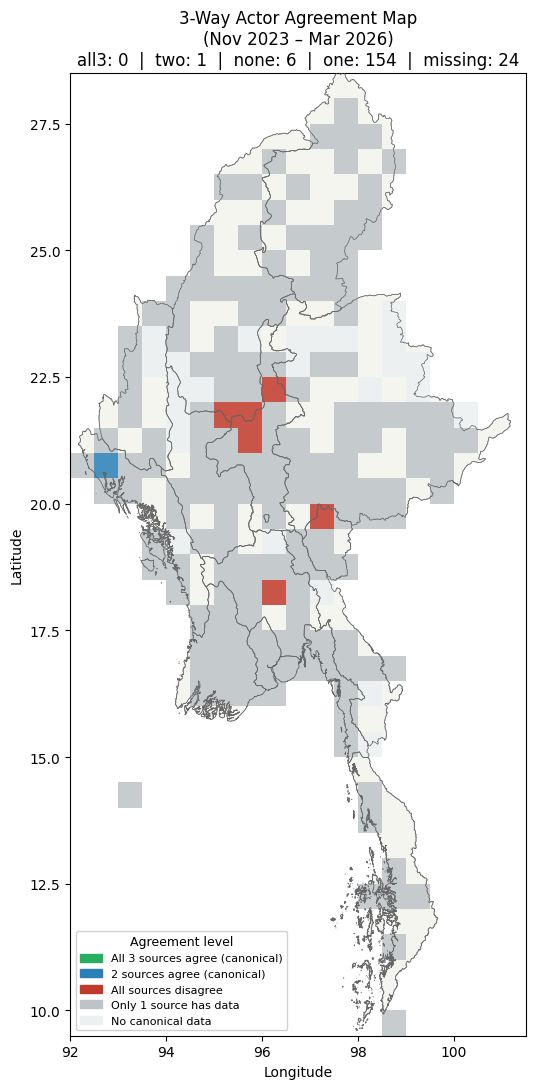

Saved: /Users/felipe/Documents/BSE/Thesis/territorial_control_dsdm_master_project/reports/figures/three_way_agreement_map.png


In [29]:
# ── Map 2: 3-way agreement map ────────────────────────────────────────────────
# Aggregate agreement signal per cell across the overlap window

def agreement_category(row):
    """
    Return agreement category for a cell-month:
    'all3'     → 3-way canonical agreement
    'two'      → any pairwise canonical agreement
    'none'     → all 3 sources present but none agree
    'one'      → only 1 source has data
    'missing'  → no source has canonical data
    """
    n = row['n_sources']
    if n == 0:
        return 'missing'
    if n == 1:
        return 'one'
    if n == 3 and row['threeway_canonical']:
        return 'all3'
    # check any pairwise
    aw = row['agree_acled_wiki_canonical']
    au = row['agree_acled_ucdp_canonical']
    wu = row['agree_wiki_ucdp_canonical']
    if any(x is True for x in [aw, au, wu]):
        return 'two'
    if n >= 2:
        return 'none'
    return 'one'

panel['agree_cat'] = panel.apply(agreement_category, axis=1)

# per cell: dominant agreement category (most common across months)
cat_order = {'all3': 4, 'two': 3, 'none': 2, 'one': 1, 'missing': 0}
panel['agree_cat_ord'] = panel['agree_cat'].map(cat_order)

cell_agree = (
    panel.groupby('priogrid_gid')['agree_cat_ord']
    .agg(lambda x: x.value_counts().index[0])
    .reset_index()
)
ord_to_cat = {v: k for k, v in cat_order.items()}
cell_agree['agree_cat'] = cell_agree['agree_cat_ord'].map(ord_to_cat)

agree_palette = {
    'all3':    '#27ae60',  # green
    'two':     '#2980b9',  # blue
    'none':    '#c0392b',  # red
    'one':     '#bdc3c7',  # grey
    'missing': '#ecf0f1',  # near-white
}
cell_agree['color'] = cell_agree['agree_cat'].map(agree_palette)

cell_gdf2 = make_cell_gdf(cell_agree, 'color')

fig, ax = plt.subplots(figsize=(8, 11))
ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)

gadm.plot(ax=ax, color='#f5f5f0', edgecolor='#999999', linewidth=0.5, zorder=1)
cell_gdf2.plot(ax=ax, color=cell_gdf2['color'], edgecolor='none', alpha=0.85, zorder=2)
gadm.boundary.plot(ax=ax, color='#666666', linewidth=0.5, zorder=3)

legend_entries2 = [
    ('All 3 sources agree (canonical)',    agree_palette['all3']),
    ('2 sources agree (canonical)',         agree_palette['two']),
    ('All sources disagree',               agree_palette['none']),
    ('Only 1 source has data',             agree_palette['one']),
    ('No canonical data',                  agree_palette['missing']),
]
patches2 = [mpatches.Patch(color=c, label=l) for l, c in legend_entries2]
ax.legend(handles=patches2, loc='lower left', fontsize=8, framealpha=0.9,
          title='Agreement level', title_fontsize=9)

cat_counts = cell_agree['agree_cat'].value_counts()
subtitle = '  |  '.join([f"{ord_to_cat[k]}: {cat_counts.get(ord_to_cat[k], 0)}"
                         for k in sorted(cat_order.values(), reverse=True)])
ax.set_title(f'3-Way Actor Agreement Map\n(Nov 2023 – Mar 2026)\n{subtitle}', fontsize=12)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()

map2_path = ROOT / 'reports' / 'figures' / 'three_way_agreement_map.png'
plt.savefig(map2_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {map2_path}')

---
## Section 6 · Summary

In [30]:
# ── collect all stats ─────────────────────────────────────────────────────────
n_panel       = len(panel)
n_all3        = len(all3)
n_at_least_2  = len(at_least_2)

tw_can_pct  = all3['threeway_canonical'].mean() if n_all3 > 0 else float('nan')
tw_side_pct = all3['threeway_side'].mean()      if n_all3 > 0 else float('nan')

aw2_pct = at_least_2['agree_acled_wiki_canonical'].dropna().mean() if n_at_least_2 > 0 else float('nan')
au2_pct = at_least_2['agree_acled_ucdp_canonical'].dropna().mean() if n_at_least_2 > 0 else float('nan')
wu2_pct = at_least_2['agree_wiki_ucdp_canonical'].dropna().mean()  if n_at_least_2 > 0 else float('nan')

print('=' * 65)
print('  NB06 ACTOR CROSSWALK — VALIDATION SUMMARY')
print('=' * 65)
print()
print(f'Overlap window          : {OVERLAP_START} → {OVERLAP_END}')
print(f'Cell-months in panel    : {n_panel:>6,}  (Wikipedia base)')
print(f'Cell-months, all 3 srcs : {n_all3:>6,}')
print(f'Cell-months, ≥ 2 srcs   : {n_at_least_2:>6,}')
print()
print('Prior NB04 status-level agreement (replicated here):')
print(f'  Mean status score     : {status_mean:.3f}   full-match rate: {status_full:.1%}')
print()
print('New NB06 actor-level direct matching:')
print(f'  Mean actor score      : {actor_mean:.3f}   full-match rate: {actor_full:.1%}')
print()
print('3-way validation (cell-months with all 3 sources):')
print(f'  3-way canonical agree : {tw_can_pct:.1%}  ({n_all3} cell-months)')
print(f'  3-way side agree      : {tw_side_pct:.1%}')
print()
print('Pairwise agreement (cell-months with ≥ 2 sources):')
print(f'  ACLED ↔ Wikipedia     : {aw2_pct:.1%}')
print(f'  ACLED ↔ UCDP          : {au2_pct:.1%}')
print(f'  Wikipedia ↔ UCDP      : {wu2_pct:.1%}')
print()
print('Implications for model labels')
print('-' * 65)
print("""
1. Actor-level direct matching (actor_score) targets specific Wikipedia
   actor labels rather than the broader control_status categories used
   in NB04. Where actor_score > status_score, the Wikipedia module is
   capturing actor attribution that the status label alone does not.

2. Low 3-way canonical agreement is expected: UCDP covers only lethal
   events while Wikipedia encodes territorial snapshots and ACLED covers
   all conflict types. Geographic precision also differs (UCDP where_prec
   ≤ 5 used here).

3. Side-level agreement is the more robust check: even if actor names
   differ across databases, sources pointing to the same broad coalition
   (Pro-junta / Anti-junta / Neutral) confirm label consistency.

4. Cells where ACLED and UCDP agree but Wikipedia disagrees may signal
   contested or transitional territory where the snapshot labelling
   captures a different moment than the event databases.

5. The crosswalk (actor_crosswalk.csv) and panel (three_way_panel.parquet)
   can be used downstream to stratify model evaluation by coalition.
""")

  NB06 ACTOR CROSSWALK — VALIDATION SUMMARY

Overlap window          : 2023-11 → 2026-03
Cell-months in panel    :  5,238  (Wikipedia base)
Cell-months, all 3 srcs :     51
Cell-months, ≥ 2 srcs   :    594

Prior NB04 status-level agreement (replicated here):
  Mean status score     : 0.361   full-match rate: 21.2%

New NB06 actor-level direct matching:
  Mean actor score      : 0.365   full-match rate: 30.7%

3-way validation (cell-months with all 3 sources):
  3-way canonical agree : 29.4%  (51 cell-months)
  3-way side agree      : 39.2%

Pairwise agreement (cell-months with ≥ 2 sources):
  ACLED ↔ Wikipedia     : 39.3%
  ACLED ↔ UCDP          : 65.4%
  Wikipedia ↔ UCDP      : 16.3%

Implications for model labels
-----------------------------------------------------------------

1. Actor-level direct matching (actor_score) targets specific Wikipedia
   actor labels rather than the broader control_status categories used
   in NB04. Where actor_score > status_score, the Wikipedia modu